## Creacion CSV jugadores por país

In [352]:
import pandas as pd
import json

In [353]:
# Ruta a tu archivo JSON
file_path = '../data/json/jugadores_todos_los_paises.json'

# 1. Cargar el archivo JSON
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# 2. Transformar la estructura
# Creamos una lista donde cada elemento es un jugador con su país incluido
lista_jugadores = []

for pais, jugadores in data.items():
    for jugador in jugadores:
        # Hacemos una copia para no modificar el diccionario original
        jugador_data = jugador.copy()
        # Agregamos la columna 'Country'
        jugador_data['Country'] = pais
        lista_jugadores.append(jugador_data)

# 3. Crear el DataFrame
df = pd.DataFrame(lista_jugadores)

# 4. (Opcional) Reordenar las columnas para que 'Country' sea la primera
columnas = ['Country'] + [col for col in df.columns if col != 'Country']
df = df[columnas]

In [354]:
# 1. Dropear la columna '#'
df = df.drop(columns=['#'])

# 2. Extraer la edad: Solo el valor entre paréntesis
# Usamos regex para buscar números dentro de paréntesis
df['Age'] = df['Age'].str.extract(r'\((\d+)\)').astype(int)

# 3. Procesar Market Value: Convertir a número (en millones)
def limpiar_valor_mercado(valor):
    if pd.isna(valor):
        return 0.0
    # Limpiamos el string
    valor = str(valor).replace('€', '').replace(',', '').strip().lower()
    
    if 'm' in valor: # Si es millones
        return float(valor.replace('m', ''))
    elif 'k' in valor: # Si es miles (ej. 200k = 0.2m)
        return float(valor.replace('k', '')) / 1000
    else:
        try:
            return float(valor)
        except:
            return 0.0

df['Market Value'] = df['Market Value'].apply(limpiar_valor_mercado)
# 5. Guardar el resultado en un CSV
df.to_csv('../data/jugadores_todos_los_paises.csv', index=False, encoding='utf-8')

In [355]:
df.sample(5)

,Country,Player,Position,Age,Club,Market Value
531,Ghana,Francis Amuzu,Left Winger,26,Grêmio Foot-Ball Porto Alegrense,9.0
227,Norway,Martin Ødegaard,Attacking Midfield,27,Arsenal FC,65.0
1237,Qatar,Hasan Al-Haydos,Attacking Midfield,35,Al-Sadd SC,0.3
402,Uruguay,Federico Viñas,Centre-Forward,27,Real Oviedo,4.0
998,Cabo Verde,Jovane Cabral,Left Winger,27,CF Estrela Amadora,0.8


<hr>

## Estudio de Selecciones "más similares"

Uso de rating de la fifa, y de ratings del juego fifa 2026

In [356]:
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import seaborn as sns

In [357]:
# Leer el archivo HTML
with open("../data/txt/fifa26_ratings_selecciones.txt", "r", encoding="utf-8") as f:
    html = f.read()

soup = BeautifulSoup(html, "html.parser")

rows = []

for tr in soup.select("tbody tr"):
    try:
        name = tr.select_one("td.s20 a").get_text(strip=True)

        formation = tr.select_one('td[data-col="fm"]').get_text(strip=True)
        overall = tr.select_one('td[data-col="oa"]').get_text(strip=True)
        attack = tr.select_one('td[data-col="at"]').get_text(strip=True)
        midfield = tr.select_one('td[data-col="md"]').get_text(strip=True)
        defence = tr.select_one('td[data-col="df"]').get_text(strip=True)
        prestige = tr.select_one('td[data-col="ip"]').get_text(strip=True)

        rows.append({
            "Name": name,
            "Formation": formation,
            "Overall": int(overall),
            "Attack": int(attack),
            "Midfield": int(midfield),
            "Defence": int(defence),
            "InternationalPrestige": int(prestige)
        })

    except Exception:
        continue

df_fifa_ratings = pd.DataFrame(rows)
df_fifa_ratings[['Formation', 'FormationType']] = (
    df_fifa_ratings['Formation']
    .str.split(' ', n=1, expand=True))
df_fifa_ratings['FormationType'] = df_fifa_ratings['FormationType'].fillna('Classic')
df_fifa_ratings = df_fifa_ratings.drop(columns=['Formation','FormationType'])
df_fifa_ratings.sample(5)

,Name,Overall,Attack,Midfield,Defence,InternationalPrestige
15,Senegal,79,79,79,78,4
48,Finland,70,75,69,64,2
26,Japan,77,78,78,77,5
44,Northern Ireland,71,66,70,70,2
18,Austria,78,77,79,78,5


In [358]:
df_fifa_ratings['AttackBalance'] = df_fifa_ratings['Attack'] - df_fifa_ratings['Defence']
df_fifa_ratings['AttackShare'] = df_fifa_ratings['Attack'] / (df_fifa_ratings['Attack'] + df_fifa_ratings['Midfield'] + df_fifa_ratings['Defence'])
df_fifa_ratings['DefenceShare'] = df_fifa_ratings['Defence'] / (df_fifa_ratings['Attack'] + df_fifa_ratings['Midfield'] + df_fifa_ratings['Defence'])
df_fifa_ratings['MidfieldShare'] = df_fifa_ratings['Midfield'] / (df_fifa_ratings['Attack'] + df_fifa_ratings['Midfield'] + df_fifa_ratings['Defence'])
df_fifa_ratings['Specialization'] = (df_fifa_ratings[['Attack', 'Midfield', 'Defence']].std(axis=1))
df_fifa_ratings['Weakness'] = (df_fifa_ratings[['Attack', 'Midfield', 'Defence']].min(axis=1))
df_fifa_ratings['Strength'] = (df_fifa_ratings[['Attack', 'Midfield', 'Defence']].max(axis=1))
df_fifa_ratings['RangeLine'] = df_fifa_ratings['Strength'] - df_fifa_ratings['Weakness'] # Para ver que tan desbalanceado es el equipo

In [359]:
df_fifa_ratings.drop(columns=['Name']).corr()

,Overall,Attack,Midfield,Defence,InternationalPrestige,AttackBalance,AttackShare,DefenceShare,MidfieldShare,Specialization,Weakness,Strength,RangeLine
Overall,1.000000,0.903573,0.971409,0.950655,0.888646,0.067249,0.006865,-0.115481,0.127951,-0.143990,0.966140,0.948361,-0.141347
Attack,0.903573,1.000000,0.858062,0.815774,0.774502,0.441136,0.414770,-0.390102,-0.135985,0.079463,0.883780,0.961643,0.077503
Midfield,0.971409,0.858062,1.000000,0.911390,0.873587,0.050489,-0.072259,-0.177962,0.317385,-0.205223,0.959135,0.911606,-0.205968
Defence,0.950655,0.815774,0.911390,1.000000,0.828795,-0.159187,-0.150571,0.159185,0.028385,-0.244714,0.953064,0.889777,-0.239944
InternationalPrestige,0.888646,0.774502,0.873587,0.828795,1.000000,0.036018,-0.042149,-0.119445,0.203809,-0.192999,0.859388,0.817194,-0.183684
AttackBalance,0.067249,0.441136,0.050489,-0.159187,0.036018,1.000000,0.941626,-0.912885,-0.276163,0.515354,0.029726,0.260834,0.504607
AttackShare,0.006865,0.414770,-0.072259,-0.150571,-0.042149,0.941626,1.000000,-0.730506,-0.578673,0.548682,-0.021221,0.224985,0.543174
DefenceShare,-0.115481,-0.390102,-0.177962,0.159185,-0.119445,-0.912885,-0.730506,1.000000,-0.134226,-0.376900,-0.075477,-0.245421,-0.365385
MidfieldShare,0.127951,-0.135985,0.317385,0.028385,0.203809,-0.276163,-0.578673,-0.134226,1.000000,-0.346069,0.120932,-0.033378,-0.351828
Specialization,-0.143990,0.079463,-0.205223,-0.244714,-0.192999,0.515354,0.548682,-0.376900,-0.346069,1.000000,-0.319016,0.119109,0.996356


In [360]:
X = df_fifa_ratings[[
    'Attack',
    'Midfield',
    'Defence',
    'InternationalPrestige',
    'AttackBalance',
    'Specialization'
]]
y = df_fifa_ratings['Name']

scaler = StandardScaler()
Z = scaler.fit_transform(X)

# Verificación: media ≈ 0 y std ≈ 1 en todas las columnas
Z_df = pd.DataFrame(Z, columns=X.columns)

In [361]:
hdr_pca = PCA()
Z_pca = hdr_pca.fit_transform(Z)

print(f'Autovalores:                    {np.round(hdr_pca.explained_variance_, 4)}')
print(f'Varianza explicada por CP:      {np.round(hdr_pca.explained_variance_ratio_, 4)}')
print(f'Varianza explicada acumulada:   {np.round(np.cumsum(hdr_pca.explained_variance_ratio_), 4)}')

Autovalores:                    [3.6309 1.7035 0.496  0.1962 0.0751 0.    ]
Varianza explicada por CP:      [0.5951 0.2792 0.0813 0.0321 0.0123 0.    ]
Varianza explicada acumulada:   [0.5951 0.8743 0.9555 0.9877 1.     1.    ]


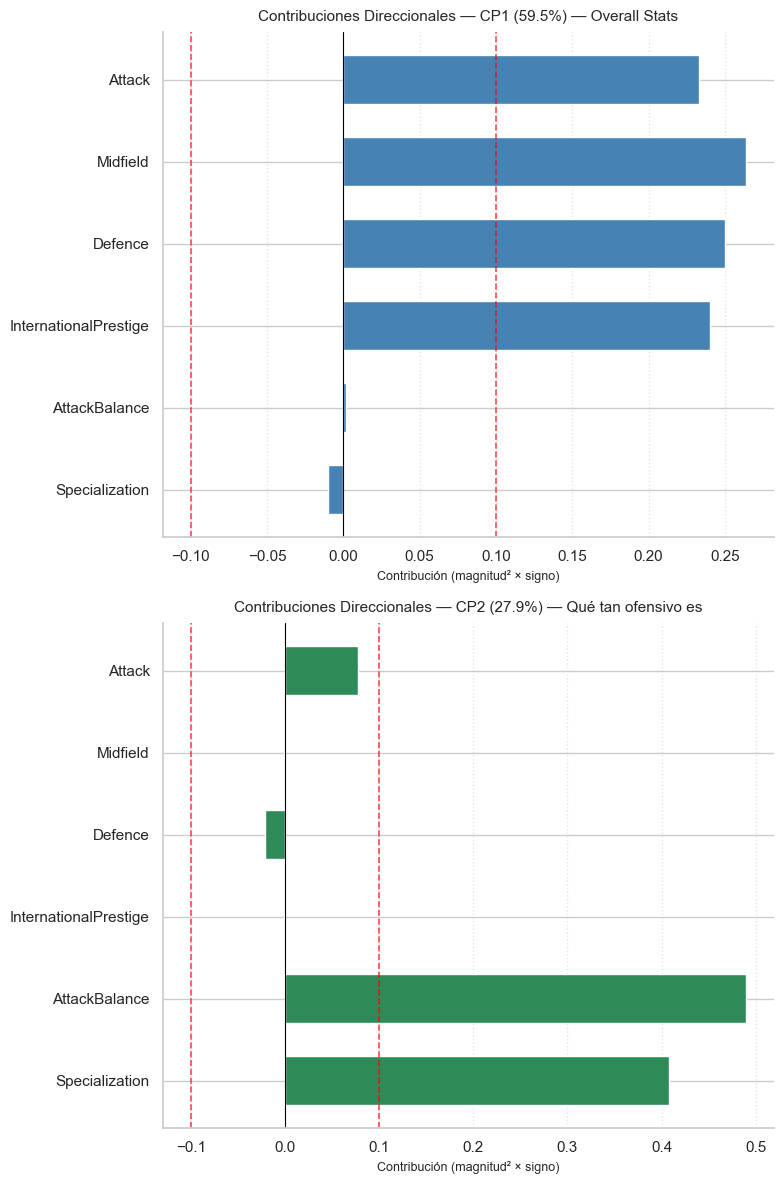

In [362]:
# Contribuciones direccionales: magnitud al cuadrado con signo del loading original
contribs_PC1 = [round(float((x**2) * np.sign(x)), 3) for x in hdr_pca.components_[0]]
contribs_PC2 = [round(float((x**2) * np.sign(x)), 3) for x in hdr_pca.components_[1]]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12))
umbral = 1/10

for ax, contribs, titulo, color in [
    (ax1, contribs_PC1, f'CP1 ({hdr_pca.explained_variance_ratio_[0]*100:.1f}%) — Overall Stats', 'steelblue'),
    (ax2, contribs_PC2, f'CP2 ({hdr_pca.explained_variance_ratio_[1]*100:.1f}%) — Qué tan ofensivo es', 'seagreen')
]:
    ax.barh(X.columns, contribs, color=color, edgecolor='white', height=0.6)
    ax.axvline(x=umbral,  color='red', linestyle='--', alpha=0.7, linewidth=1.2, label='Umbral (+)')
    ax.axvline(x=-umbral, color='red', linestyle='--', alpha=0.7, linewidth=1.2, label='Umbral (-)')
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(f'Contribuciones Direccionales — {titulo}', fontsize=11, pad=8)
    ax.set_xlabel('Contribución (magnitud² × signo)', fontsize=9)
    ax.invert_yaxis()
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

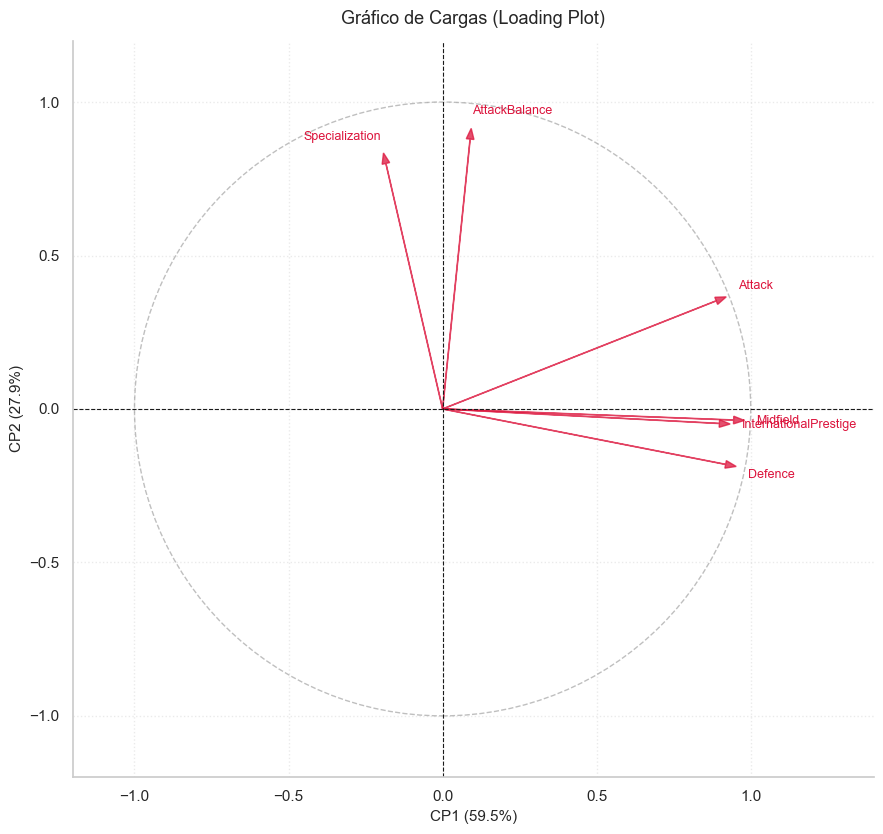

In [363]:
# Gráfico de cargas (biplot de variables)
# Los loadings son las correlaciones entre cada variable y cada componente
# Se escalan por sqrt(autovalor) para reflejar la varianza real explicada
loadings = hdr_pca.components_.T * np.sqrt(hdr_pca.explained_variance_)

fig, ax = plt.subplots(figsize=(9, 8.5))
circle = Circle((0, 0), 1, facecolor='none', edgecolor='gray', linestyle='--', alpha=0.5)
ax.add_patch(circle)
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8)
ax.axvline(x=0, color='k', linestyle='--', linewidth=0.8)

for i in range(loadings.shape[0]):
    x_arrow, y_arrow = loadings[i, 0], loadings[i, 1]
    ax.arrow(0, 0, x_arrow, y_arrow, color='crimson', alpha=0.75,
             head_width=0.025, head_length=0.035, length_includes_head=True)
    ha_align = 'left' if x_arrow >= 0 else 'right'
    va_align = 'center' if abs(y_arrow) < 0.05 else ('bottom' if y_arrow >= 0 else 'top')
    ax.text(x_arrow * 1.04, y_arrow * 1.04, X.columns[i],
            color='crimson', ha=ha_align, va=va_align, fontsize=9)

ax.set_xlabel(f'CP1 ({hdr_pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'CP2 ({hdr_pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
ax.set_title('Gráfico de Cargas (Loading Plot)', fontsize=13, pad=12)
ax.set_xlim(-1.2, 1.4)
ax.set_ylim(-1.2, 1.2)
ax.grid(linestyle=':', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

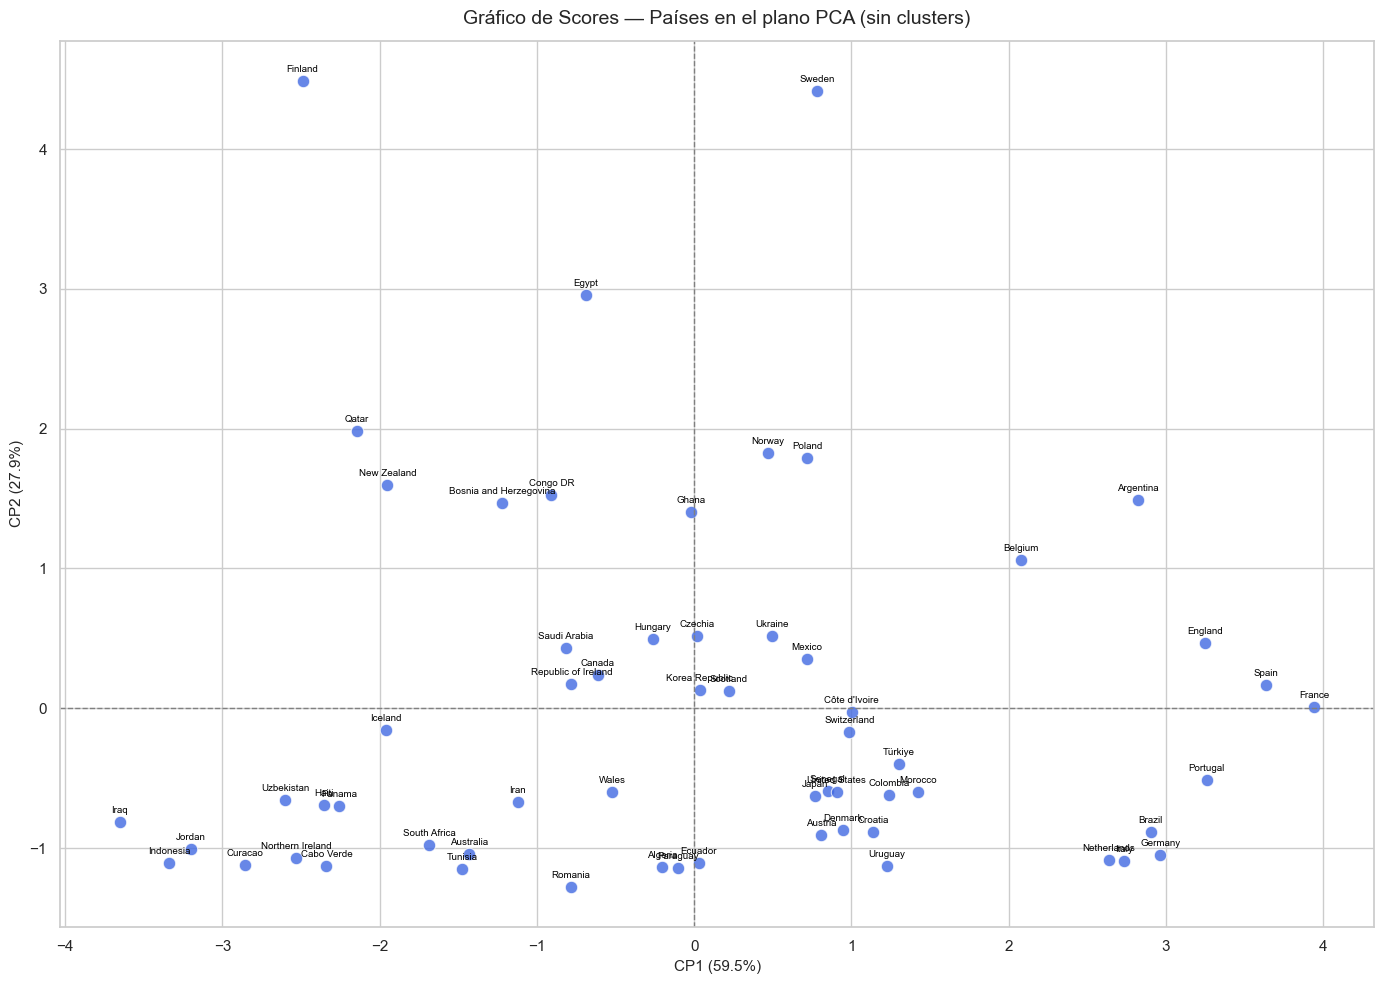

In [364]:
Z_pca_df = pd.DataFrame(Z_pca[:, :2], columns=['CP1', 'CP2'])
Z_pca_df['country'] = y.values

label_x = f"CP1 ({hdr_pca.explained_variance_ratio_[0]*100:.1f}%)"
label_y = f"CP2 ({hdr_pca.explained_variance_ratio_[1]*100:.1f}%)"

plt.figure(figsize=(14, 10), dpi=100)
sns.set_theme(style='whitegrid')
sns.scatterplot(data=Z_pca_df, x='CP1', y='CP2', s=80, color='royalblue', alpha=0.8)

for i in range(len(Z_pca_df)):
    plt.text(Z_pca_df['CP1'].iloc[i], Z_pca_df['CP2'].iloc[i] + 0.05,
             Z_pca_df['country'].iloc[i], fontsize=7, ha='center', va='bottom', color='black')

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Gráfico de Scores — Países en el plano PCA (sin clusters)', fontsize=14, pad=12)
plt.xlabel(label_x, fontsize=11)
plt.ylabel(label_y, fontsize=11)
plt.tight_layout()
plt.show()

<hr>

## Estudio de partidos "más similares"

In [365]:
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import seaborn as sns

In [366]:
pd.set_option('display.max_columns', None)

In [367]:
df_fifa_ratings_3 = df_fifa_ratings[[
    'Name',
    'Attack',
    'Midfield',
    'Defence',
    'Overall',
    'InternationalPrestige',
    'AttackBalance',
    'Specialization'
]]

In [368]:
matches = pd.read_csv("../data/matriz_partidos.csv")
matches.head(3)

,id_partido,home_team,away_team,day_of_week_num,is_weekend,ELO_match_rating,ELO_diff,home_value,away_value,match_value,match_value_diff,match_hora_utc
0,1,Korea Republic,Czechia,4,0,3478,26,143.400,196.425,339.825,53.025,2
1,2,Mexico,South Africa,3,0,3382,334,85.600,52.700,138.300,32.900,19
2,3,Czechia,South Africa,3,0,3250,202,196.425,52.700,249.125,143.725,16


In [369]:
matches['home_team'] = (
    matches['home_team']
    .str.replace('Bosnia-Herzegovina', 'Bosnia and Herzegovina')
    .str.replace('USA', 'United States')
    .str.replace('Turkey', 'Türkiye')
    .str.replace('Curaçao', 'Curacao')
    .str.replace('IR Iran', 'Iran')
    )

matches['away_team'] = (
    matches['away_team']
    .str.replace('Bosnia-Herzegovina', 'Bosnia and Herzegovina')
    .str.replace('USA', 'United States')
    .str.replace('Turkey', 'Türkiye')
    .str.replace('Curaçao', 'Curacao')
    .str.replace('IR Iran', 'Iran')
    )

In [370]:
matches_1 = matches.merge(df_fifa_ratings_3, left_on='home_team', right_on='Name', how='left', suffixes=('','_home'))
matches_2 = matches_1.merge(df_fifa_ratings_3, left_on='away_team', right_on='Name', how='left', suffixes=('_home','_away'))
matches_2.head(5)

,id_partido,home_team,away_team,day_of_week_num,is_weekend,ELO_match_rating,ELO_diff,home_value,away_value,match_value,match_value_diff,match_hora_utc,Name_home,Attack_home,Midfield_home,Defence_home,Overall_home,InternationalPrestige_home,AttackBalance_home,Specialization_home,Name_away,Attack_away,Midfield_away,Defence_away,Overall_away,InternationalPrestige_away,AttackBalance_away,Specialization_away
0,1,Korea Republic,Czechia,4,0,3478,26,143.400,196.425,339.825,53.025,2,Korea Republic,77,74,75,75,5,2,1.527525,Czechia,78,75,75,77,4,3,1.732051
1,2,Mexico,South Africa,3,0,3382,334,85.600,52.700,138.300,32.900,19,Mexico,78,76,75,76,7,3,1.527525,South Africa,70,69,70,70,4,0,0.577350
2,3,Czechia,South Africa,3,0,3250,202,196.425,52.700,249.125,143.725,16,Czechia,78,75,75,77,4,3,1.732051,South Africa,70,69,70,70,4,0,0.577350
3,4,Mexico,Korea Republic,4,0,3610,106,85.600,143.400,229.000,57.800,1,Mexico,78,76,75,76,7,3,1.527525,Korea Republic,77,74,75,75,5,2,1.527525
4,5,South Africa,Korea Republic,3,0,3276,228,52.700,143.400,196.100,90.700,1,South Africa,70,69,70,70,4,0,0.577350,Korea Republic,77,74,75,75,5,2,1.527525


In [371]:
matches_2['ELO_match_rating'] = matches_2['ELO_match_rating']/2
matches_2['Attack_adv'] = abs((matches_2['Attack_home'] - matches_2['Defence_away']) - (matches_2['Attack_away'] - matches_2['Defence_home']))
matches_2['Attack_diff'] = abs(matches_2['Attack_home'] - matches_2['Attack_away'])
matches_2['Midfield_diff'] = abs(matches_2['Midfield_home'] - matches_2['Midfield_away'])
matches_2['Defence_diff'] = abs(matches_2['Defence_home'] - matches_2['Defence_away'])
matches_2['Mean_Attack'] = (matches_2['Attack_home'] + matches_2['Attack_away']) / 2
matches_2['Mean_Midfield'] = (matches_2['Midfield_home'] + matches_2['Midfield_away']) / 2
matches_2['Mean_Defence'] = (matches_2['Defence_home'] + matches_2['Defence_away']) / 2
matches_2['Overall_Diff'] = abs(matches_2['Overall_home'] - matches_2['Overall_away'])

matches_2 = matches_2.drop(columns=['home_value','away_value'])

In [372]:
matches_2['match'] = matches_2['home_team'] + ' vs ' + matches_2['away_team']
matches_2 = matches_2.drop(columns=['home_team','away_team','day_of_week_num','is_weekend','match_hora_utc'])
matches_3 = matches_2[[
    'id_partido',
    'match',
    'ELO_match_rating',
    'Attack_adv',
    'Attack_diff',
    'Midfield_diff',
    'Defence_diff',
    'Mean_Attack',
    'Mean_Midfield',
    'Mean_Defence',
    'Overall_Diff'
]]

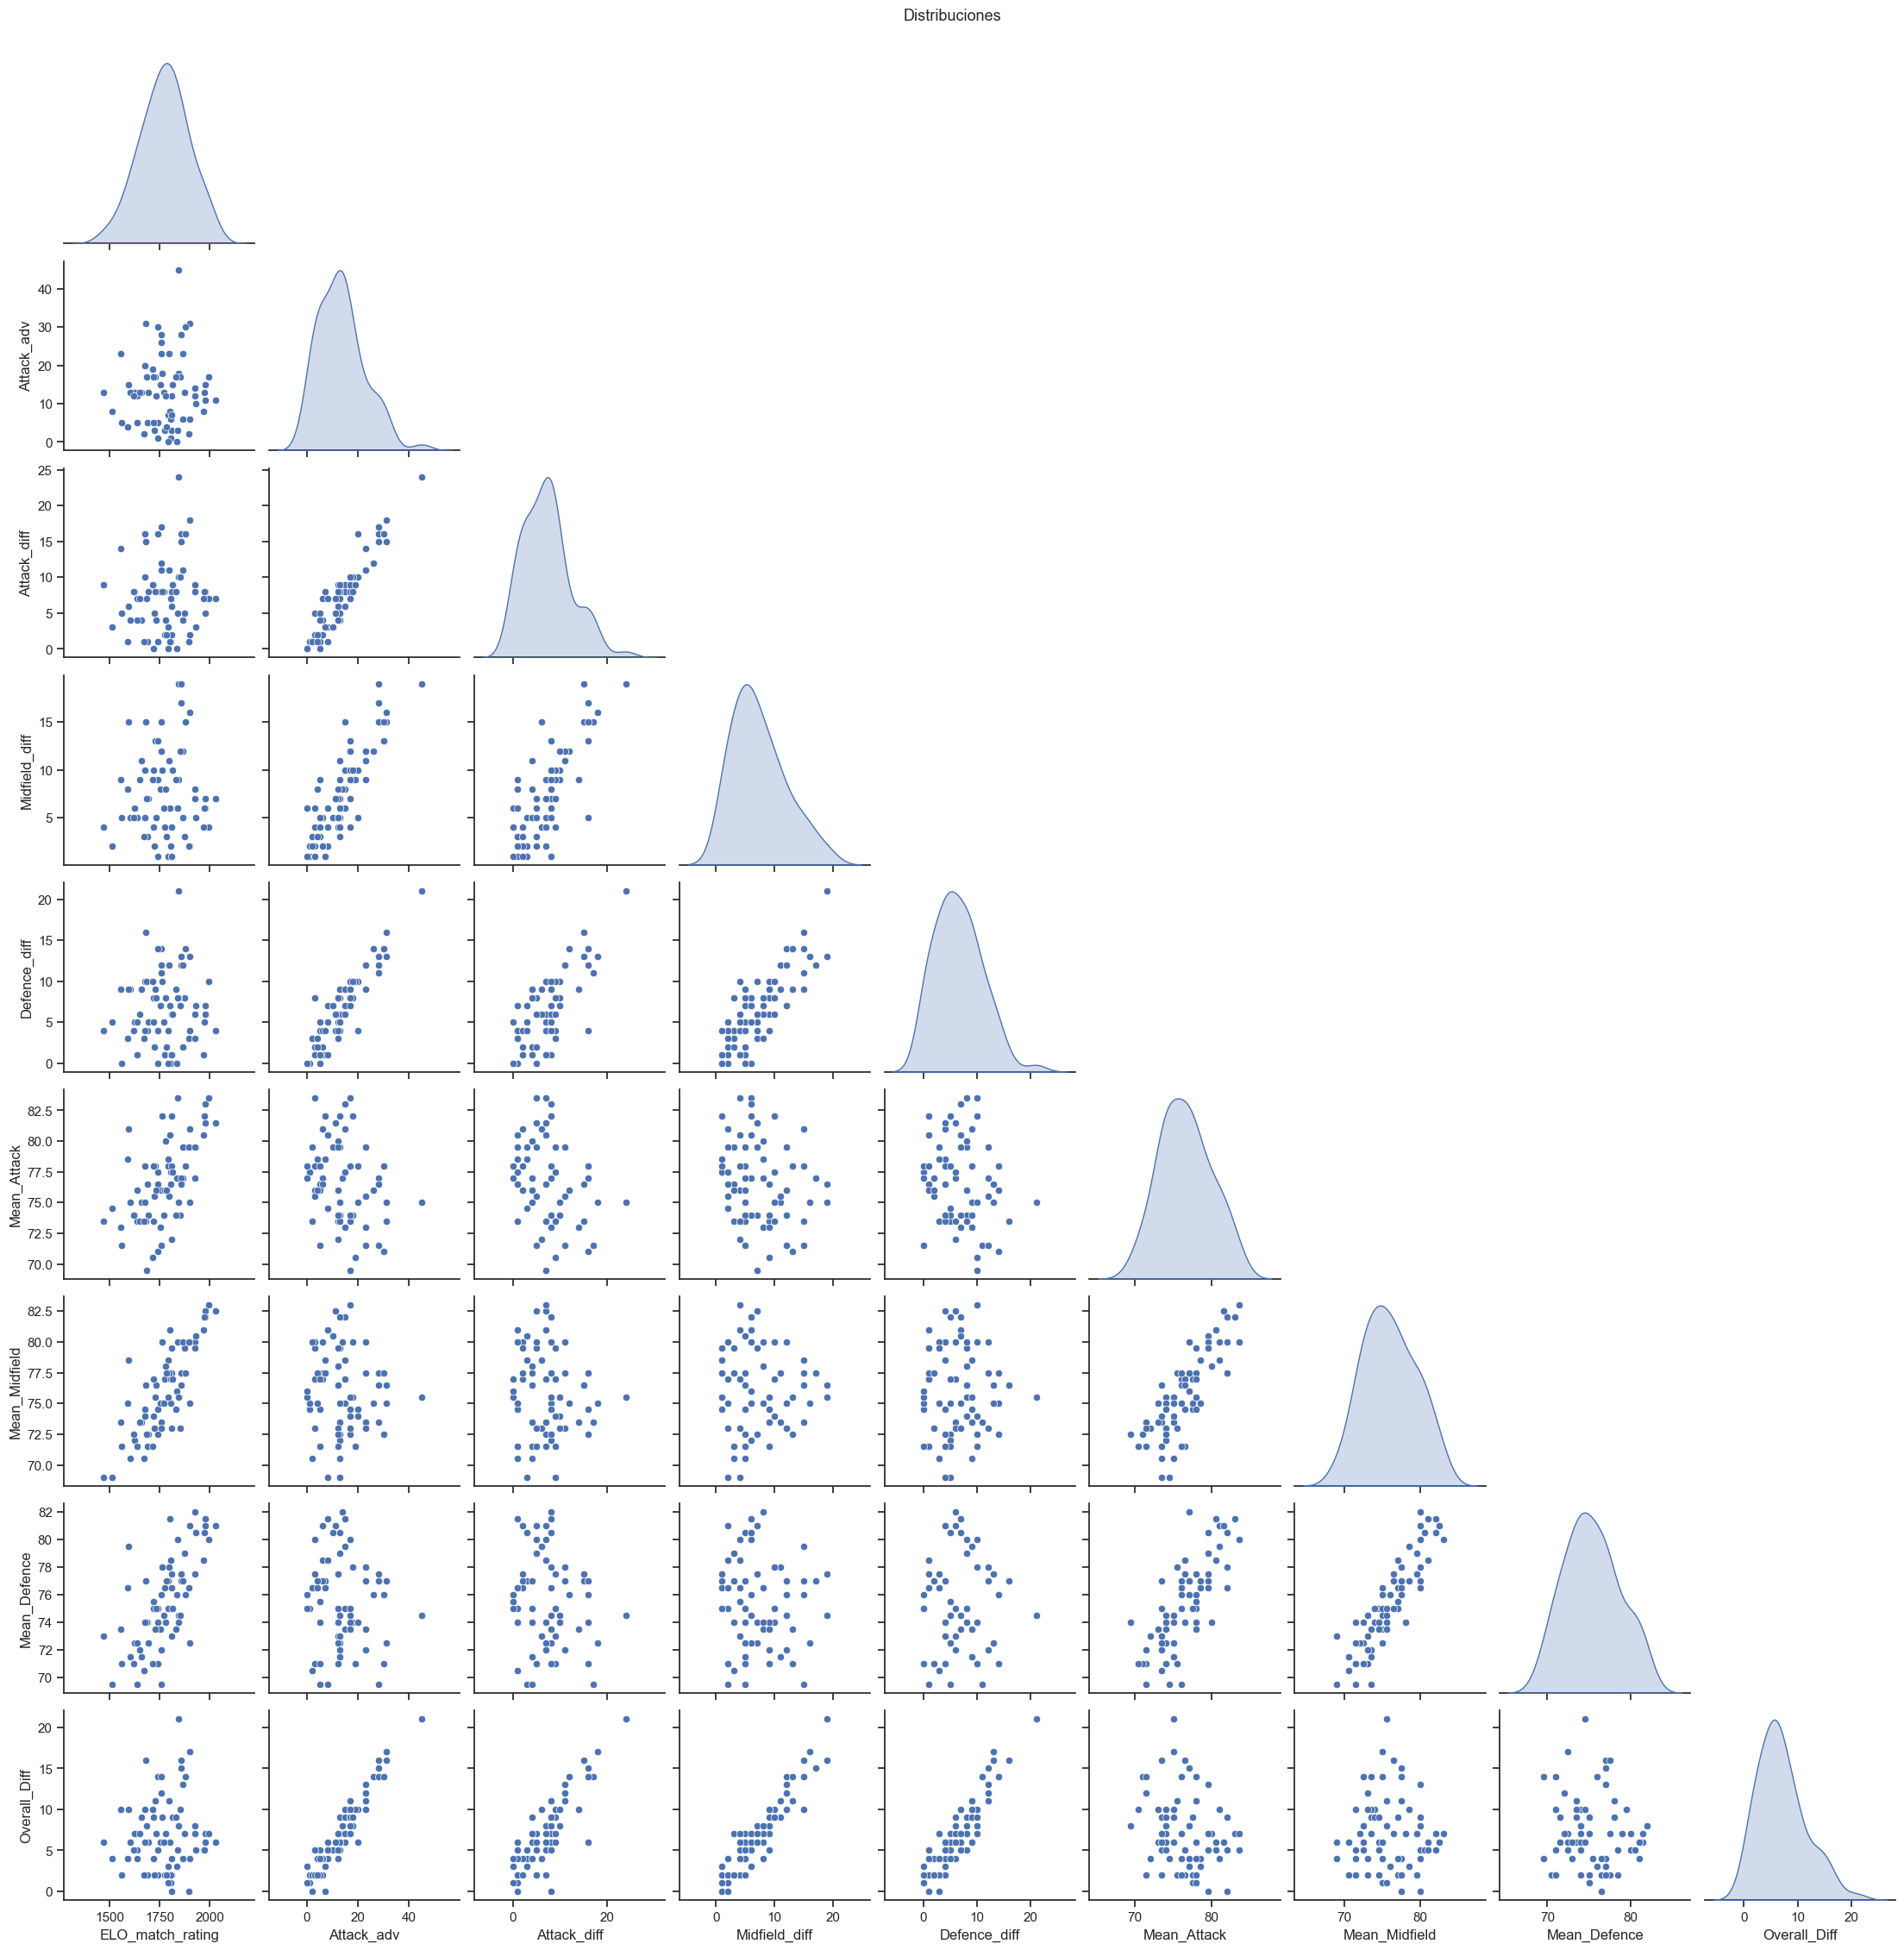

In [373]:
# Pairplot post-transformación
sns.set_theme(style='ticks')
sns.pairplot(matches_3.drop(columns=['id_partido','match']), diag_kind='kde', corner=True)
plt.suptitle('Distribuciones', y=1.01, fontsize=13)
plt.show()

In [374]:
# X = df_fifa_ratings.drop(columns=['Name','Weakness','Strength','RangeLine','AttackBalance','Overall'])
X = matches_3.drop(columns=['match','id_partido'])
y = matches_3['match']

scaler = StandardScaler()
Z = scaler.fit_transform(X)

# Verificación: media ≈ 0 y std ≈ 1 en todas las columnas
Z_df = pd.DataFrame(Z, columns=X.columns)

In [375]:
hdr_pca = PCA()
Z_pca = hdr_pca.fit_transform(Z)

print(f'Autovalores:                    {np.round(hdr_pca.explained_variance_, 4)}')
print(f'Varianza explicada por CP:      {np.round(hdr_pca.explained_variance_ratio_, 4)}')
print(f'Varianza explicada acumulada:   {np.round(np.cumsum(hdr_pca.explained_variance_ratio_), 4)}')

Autovalores:                    [4.6883 3.2589 0.4295 0.263  0.2104 0.1793 0.0606 0.0255 0.0112]
Varianza explicada por CP:      [0.5137 0.3571 0.0471 0.0288 0.0231 0.0197 0.0066 0.0028 0.0012]
Varianza explicada acumulada:   [0.5137 0.8708 0.9178 0.9466 0.9697 0.9893 0.996  0.9988 1.    ]


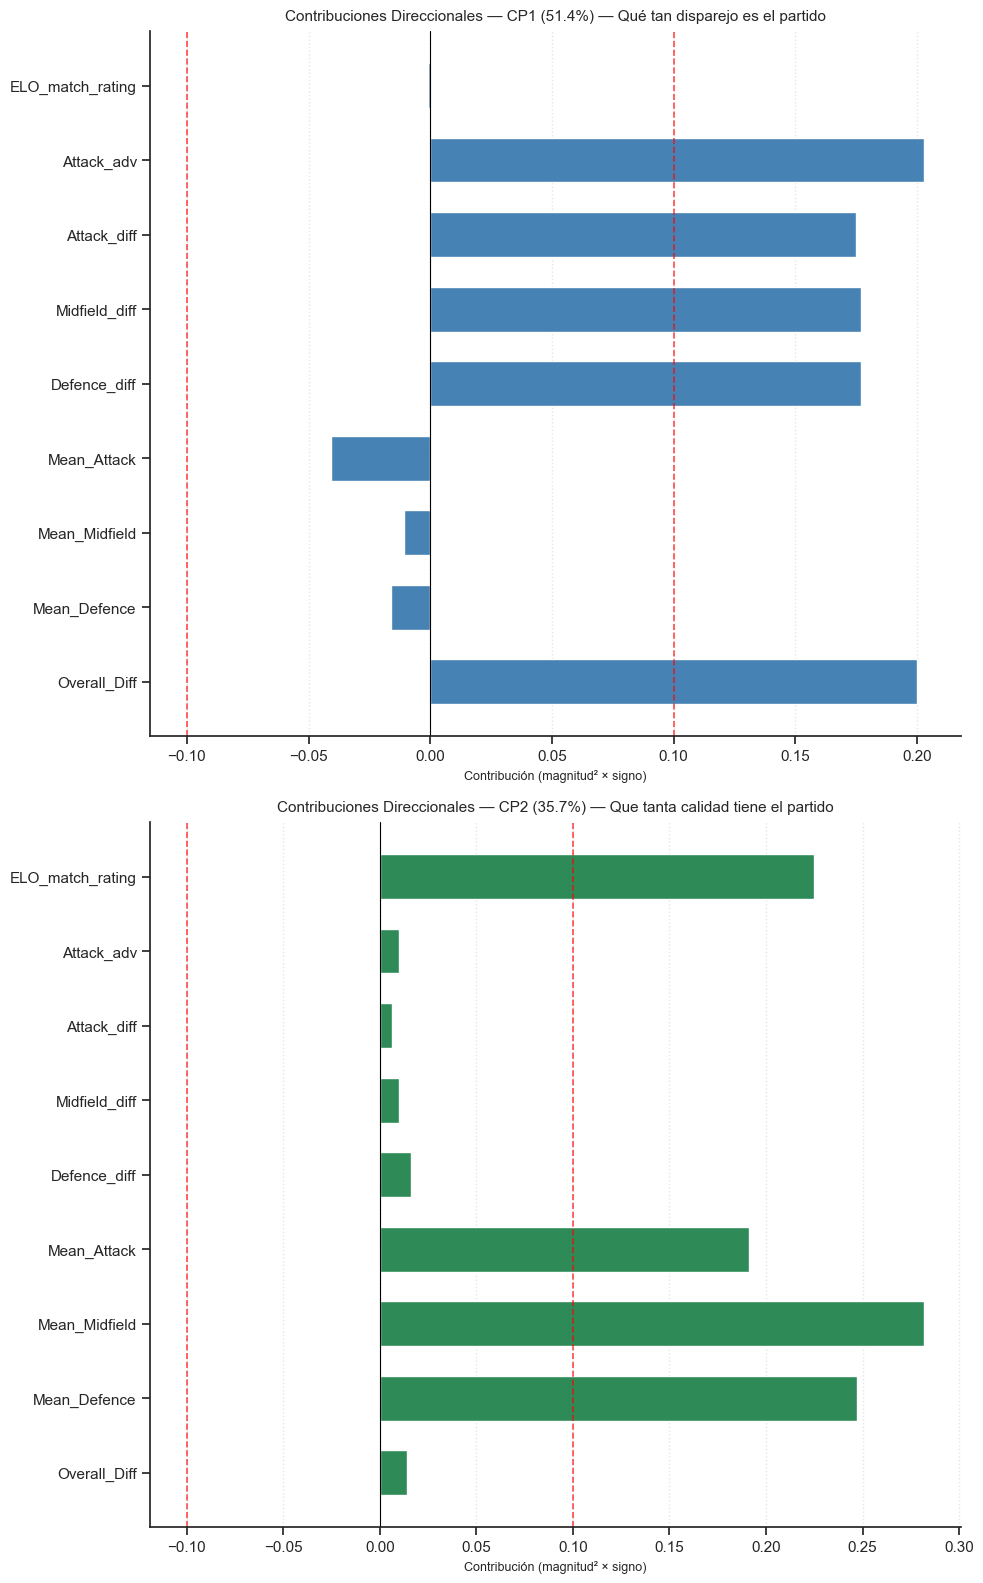

In [376]:
# Contribuciones direccionales: magnitud al cuadrado con signo del loading original
contribs_PC1 = [round(float((x**2) * np.sign(x)), 3) for x in hdr_pca.components_[0]]
contribs_PC2 = [round(float((x**2) * np.sign(x)), 3) for x in hdr_pca.components_[1]]
# contribs_PC3 = [round(float((x**2) * np.sign(x)), 3) for x in hdr_pca.components_[2]]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 16))
umbral = 1/10

for ax, contribs, titulo, color in [
    (ax1, contribs_PC1, f'CP1 ({hdr_pca.explained_variance_ratio_[0]*100:.1f}%) — Qué tan disparejo es el partido', 'steelblue'),
    (ax2, contribs_PC2, f'CP2 ({hdr_pca.explained_variance_ratio_[1]*100:.1f}%) — Que tanta calidad tiene el partido', 'seagreen'),
    # (ax3, contribs_PC3, f'CP3 ({hdr_pca.explained_variance_ratio_[2]*100:.1f}%) — Componente residual', 'indianred'),
]:
    ax.barh(X.columns, contribs, color=color, edgecolor='white', height=0.6)
    ax.axvline(x=umbral,  color='red', linestyle='--', alpha=0.7, linewidth=1.2, label='Umbral (+)')
    ax.axvline(x=-umbral, color='red', linestyle='--', alpha=0.7, linewidth=1.2, label='Umbral (-)')
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(f'Contribuciones Direccionales — {titulo}', fontsize=11, pad=8)
    ax.set_xlabel('Contribución (magnitud² × signo)', fontsize=9)
    ax.invert_yaxis()
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

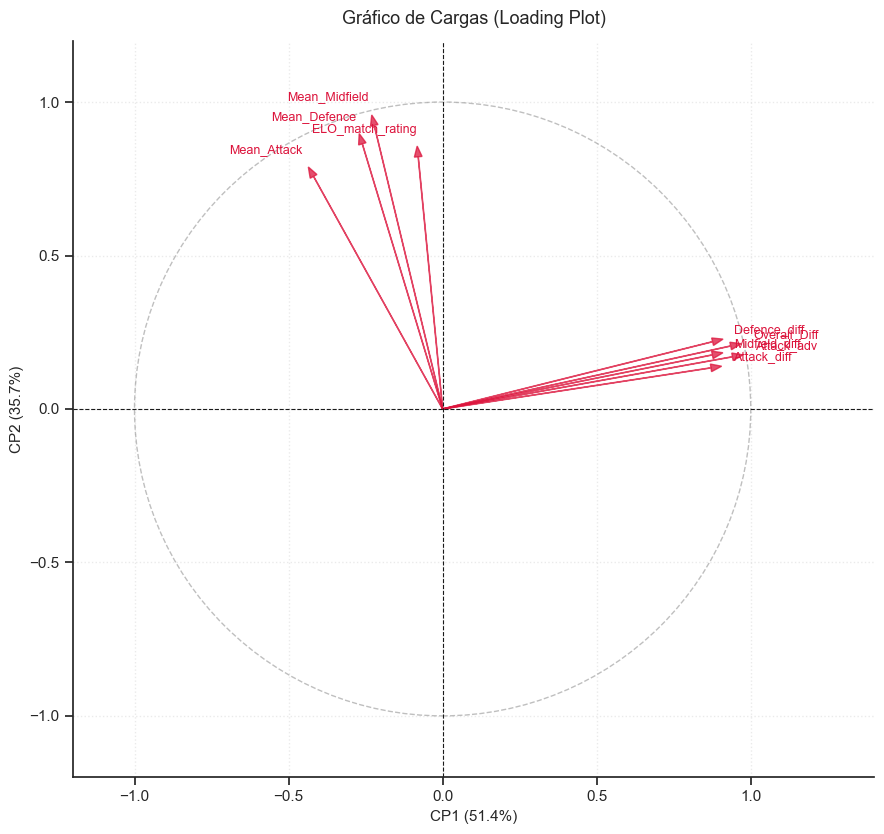

In [377]:
# Gráfico de cargas (biplot de variables)
# Los loadings son las correlaciones entre cada variable y cada componente
# Se escalan por sqrt(autovalor) para reflejar la varianza real explicada
loadings = hdr_pca.components_.T * np.sqrt(hdr_pca.explained_variance_)

fig, ax = plt.subplots(figsize=(9, 8.5))
circle = Circle((0, 0), 1, facecolor='none', edgecolor='gray', linestyle='--', alpha=0.5)
ax.add_patch(circle)
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8)
ax.axvline(x=0, color='k', linestyle='--', linewidth=0.8)

for i in range(loadings.shape[0]):
    x_arrow, y_arrow = loadings[i, 0], loadings[i, 1]
    ax.arrow(0, 0, x_arrow, y_arrow, color='crimson', alpha=0.75,
             head_width=0.025, head_length=0.035, length_includes_head=True)
    ha_align = 'left' if x_arrow >= 0 else 'right'
    va_align = 'center' if abs(y_arrow) < 0.05 else ('bottom' if y_arrow >= 0 else 'top')
    ax.text(x_arrow * 1.04, y_arrow * 1.04, X.columns[i],
            color='crimson', ha=ha_align, va=va_align, fontsize=9)

ax.set_xlabel(f'CP1 ({hdr_pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'CP2 ({hdr_pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
ax.set_title('Gráfico de Cargas (Loading Plot)', fontsize=13, pad=12)
ax.set_xlim(-1.2, 1.4)
ax.set_ylim(-1.2, 1.2)
ax.grid(linestyle=':', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

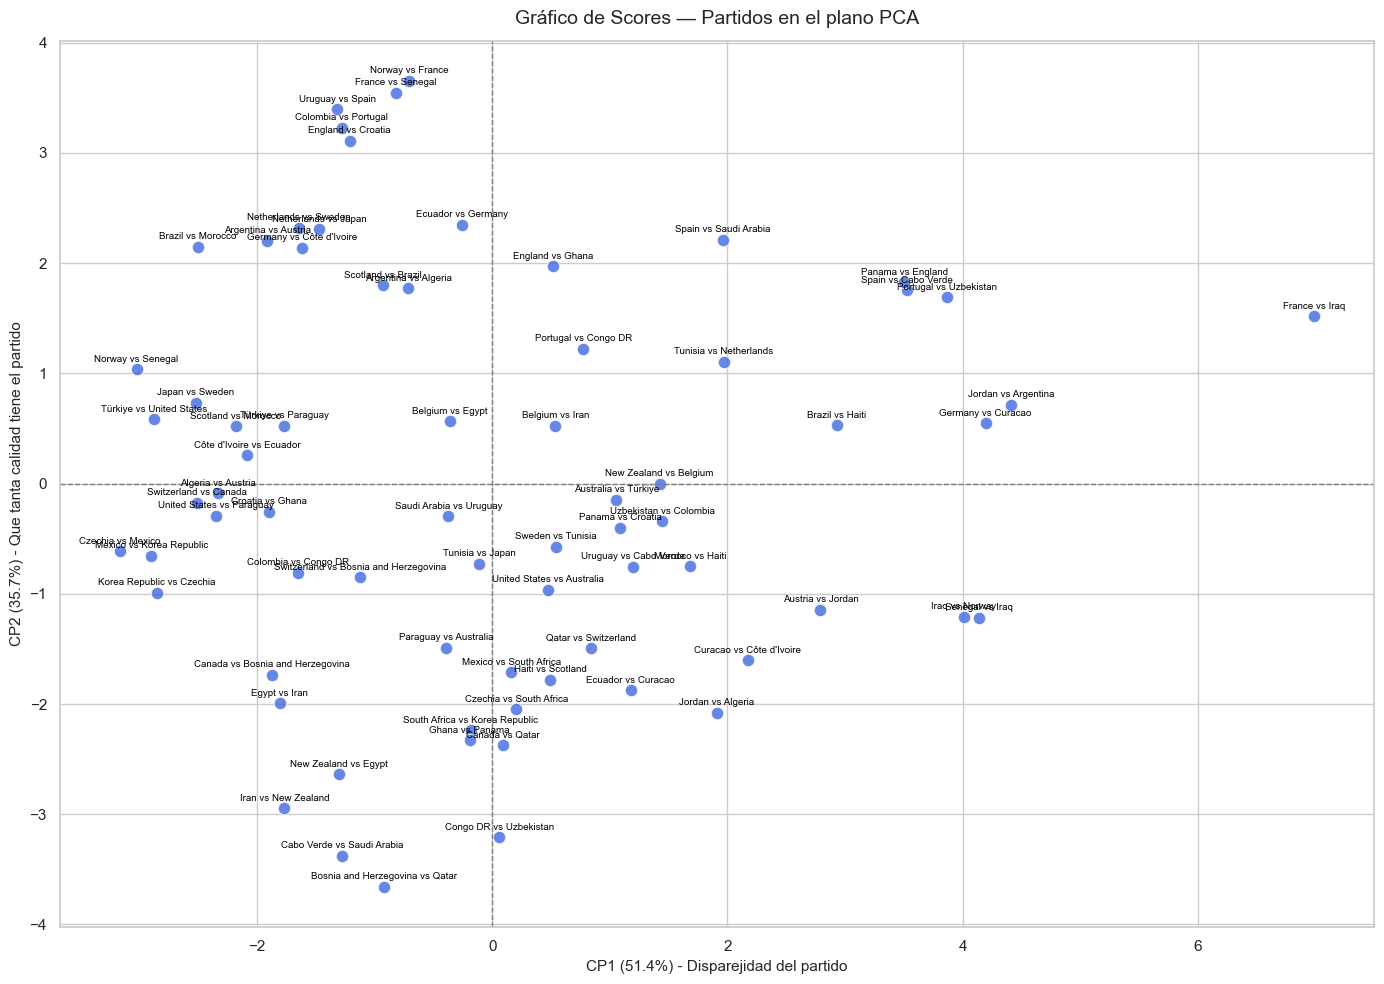

In [378]:
Z_pca_df = pd.DataFrame(Z_pca[:, :2], columns=['CP1', 'CP2'])
Z_pca_df['country'] = y.values

label_x = f"CP1 ({hdr_pca.explained_variance_ratio_[0]*100:.1f}%) - Disparejidad del partido"
label_y = f"CP2 ({hdr_pca.explained_variance_ratio_[1]*100:.1f}%) - Que tanta calidad tiene el partido"

plt.figure(figsize=(14, 10), dpi=100)
sns.set_theme(style='whitegrid')
sns.scatterplot(data=Z_pca_df, x='CP1', y='CP2', s=80, color='royalblue', alpha=0.8)

for i in range(len(Z_pca_df)):
    plt.text(Z_pca_df['CP1'].iloc[i], Z_pca_df['CP2'].iloc[i] + 0.05,
             Z_pca_df['country'].iloc[i], fontsize=7, ha='center', va='bottom', color='black')

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Gráfico de Scores — Partidos en el plano PCA', fontsize=14, pad=12)
plt.xlabel(label_x, fontsize=11)
plt.ylabel(label_y, fontsize=11)
plt.tight_layout()
plt.show()